# 04 · Estrategias de imputación: comparadas con evidencia

**Fase CRISP-DM: Preparación de los datos.**

Los tres notebooks anteriores dejaron el terreno preparado: el notebook 00 midió el tamaño
del problema (10–30% de nulos en vitales, >90% en labs), el notebook 02 mostró que esa
ausencia **no es aleatoria** —sigue el protocolo médico y depende de si el paciente termina
séptico— y el notebook 03 encontró que promediar por hora un laboratorio disperso es
demasiado ruidoso para ser confiable. Ninguno de los tres, sin embargo, respondió la pregunta
que hace falta antes de modelar: **¿con qué valor, exactamente, se llena cada hueco?**

Este notebook no elige la respuesta por intuición. La pone a prueba: enmascaramos valores
reales que sí conocemos, los tapamos como si fueran nulos, e intentamos recuperarlos con
distintos métodos — así medimos el error de cada estrategia contra la verdad, no contra una
suposición.

### La regla que no se negocia: causalidad

Para predecir la hora *t*, solo puede usarse información disponible hasta *t*. Por eso quedan
descartados de entrada, sin necesidad de probarlos: `interpolate()` (usa el valor futuro para
rellenar el pasado) y cualquier estadístico (media, mediana, desviación) calculado sobre la
estancia completa del paciente o sobre el set de test. Todo lo que sigue respeta esa regla
—excepto un método que se incluye **a propósito** para mostrar qué tan tentador y qué tan
peligroso es romperla.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
import io_datos
import viz
from config import cargar_config

cfg = cargar_config()
df = io_datos.leer_cohorte(cfg).sort_values(["pid", "ICULOS"]).reset_index(drop=True)
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

rng = np.random.default_rng(cfg["proyecto"]["semilla"])

## 1. Cuatro candidatos

| Método | Causal? | Idea |
|---|---|---|
| Media global | Sí (si se calcula solo en train) | Rellenar con el promedio de toda la cohorte |
| Mediana del propio paciente | **No** | Rellenar con la mediana de *todas* las horas del paciente, pasadas y futuras |
| Arrastre causal (`ffill`) | Sí | Rellenar con el último valor real conocido de ese mismo paciente |
| Dejar el nulo | Sí | No rellenar; delegar en un modelo que soporte NaN nativamente |

La "mediana del paciente" está marcada como no causal a propósito: en la hora 5 de estancia,
usar la mediana de *toda* la estancia (incluida la hora 40) es tramposo — en el momento de
predecir, esa información del futuro no existe. La incluimos solo como referencia de cuánto
"ayuda" hacer trampa, para poder decir con números cuánto se pierde al jugar limpio.

## 2. Experimento: enmascarar valores reales y tratar de recuperarlos

Tomamos las horas donde una variable **sí** tiene un valor real, ocultamos aleatoriamente el
20% de ellas, y comparamos qué tan cerca del valor verdadero queda cada método. Repetimos para
dos signos vitales densos (`HR`, `MAP`) y dos laboratorios dispersos (`Creatinine`, `WBC`), para
ver si la mejor estrategia es la misma en ambos casos.

In [2]:
def experimento_mascara(var, frac=0.2):
    obs = df[df[var].notna()].copy()
    n_mask = int(len(obs) * frac)
    idx_mask = rng.choice(obs.index, size=n_mask, replace=False)

    serie = df[var].copy()
    serie_oculta = serie.copy()
    serie_oculta.loc[idx_mask] = np.nan

    # ffill causal: solo ve la serie con los valores ocultos, nunca el valor real que tapamos
    ffill_causal = serie_oculta.groupby(df["pid"], observed=True).ffill()

    # mediana de TODO el paciente (incluye futuro) -- deliberadamente no causal, ver Sección 1
    trampa_mediana_paciente = df.groupby("pid", observed=True)[var].transform("median")

    media_global = serie[~df.index.isin(idx_mask)].mean()

    real = serie.loc[idx_mask]
    resultados = {}
    for nombre, pred in [
        ("Media global", pd.Series(media_global, index=idx_mask)),
        ("Mediana del paciente (trampa, no causal)", trampa_mediana_paciente.loc[idx_mask]),
        ("Último valor conocido (ffill causal)", ffill_causal.loc[idx_mask]),
    ]:
        valido = pred.notna() & real.notna()
        mae = (pred[valido] - real[valido]).abs().mean()
        resultados[nombre] = {"MAE": round(mae, 3), "cobertura_%": round(valido.mean() * 100, 1)}
    return pd.DataFrame(resultados).T


for var in ["HR", "MAP", "Creatinine", "WBC"]:
    print(f"--- {var} ---")
    print(experimento_mascara(var).to_string())
    print()

--- HR ---


                                             MAE  cobertura_%
Media global                              13.761        100.0
Mediana del paciente (trampa, no causal)   6.776        100.0
Último valor conocido (ffill causal)       5.258         96.4

--- MAP ---


                                             MAE  cobertura_%
Media global                              12.611        100.0
Mediana del paciente (trampa, no causal)   7.698        100.0
Último valor conocido (ffill causal)       8.088         96.3

--- Creatinine ---


                                            MAE  cobertura_%
Media global                              0.995        100.0
Mediana del paciente (trampa, no causal)  0.136        100.0
Último valor conocido (ffill causal)      0.226         52.8

--- WBC ---


                                            MAE  cobertura_%
Media global                              4.186        100.0
Mediana del paciente (trampa, no causal)  1.310        100.0
Último valor conocido (ffill causal)      1.993         55.5



Cuatro resultados, y no todos dicen lo mismo:

- **`HR`**: el arrastre causal (MAE 5,26) es el mejor de los tres — incluso mejor que la
  "trampa" (6,78) — y ambos golean a la media global (13,76, más del doble de error). Aquí
  jugar limpio no cuesta nada: el último valor real es, literalmente, la mejor predicción
  disponible, con o sin trampa.
- **`MAP`**: la trampa (7,70) gana por poco al arrastre causal (8,09) — una diferencia de solo
  5%, frente a la media global (12,61), que sigue siendo la peor opción por lejos.
- **`Creatinine` y `WBC`**: aquí sí hay una historia distinta. La trampa golea al arrastre
  causal (Creatinine: 0,136 vs 0,226; WBC: 1,31 vs 1,99) — son variables "lentas" donde
  *cualquier* valor del paciente, incluso uno futuro, predice bien los demás. Pero lo más
  importante no es el MAE: es la **cobertura**. El arrastre causal solo logra recuperar el
  52,8% (Creatinine) y 55,5% (WBC) de los valores ocultos — el resto de las veces, el paciente
  no tiene ningún valor real *anterior* de esa variable para arrastrar. La media global, en
  cambio, siempre "cubre" el 100% — pero a costa de un error 4–7 veces mayor.

**La lectura correcta no es "usar la trampa"** —eso sería fuga de información— sino entender
que para los laboratorios dispersos, casi la mitad de las horas se van a quedar **sin ningún
valor arrastrable**, y el modelo necesita saberlo explícitamente en vez de que se le oculte.
Es exactamente el problema que ya resuelven las features `{variable}_medido` y
`{variable}_edad` de `src/features.py`: cuando no hay nada que arrastrar, el modelo ve un nulo
real, no un número inventado que parezca información.

## 3. ¿Cuánto empeora el arrastre según la antigüedad del valor?

El experimento anterior no dice hasta cuándo conviene arrastrar un valor. Lo medimos de forma
distinta: para cada paciente, tomamos pares de mediciones reales **consecutivas** (sin ocultar
nada) y medimos qué tan lejos está la segunda medición de la primera, en función de cuántas
horas pasaron entre ambas. Es la pregunta que responde directamente al parámetro
`max_horas_ffill` de `config.yaml`.

WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/04_error_arrastre_vs_antiguedad_valor.png')

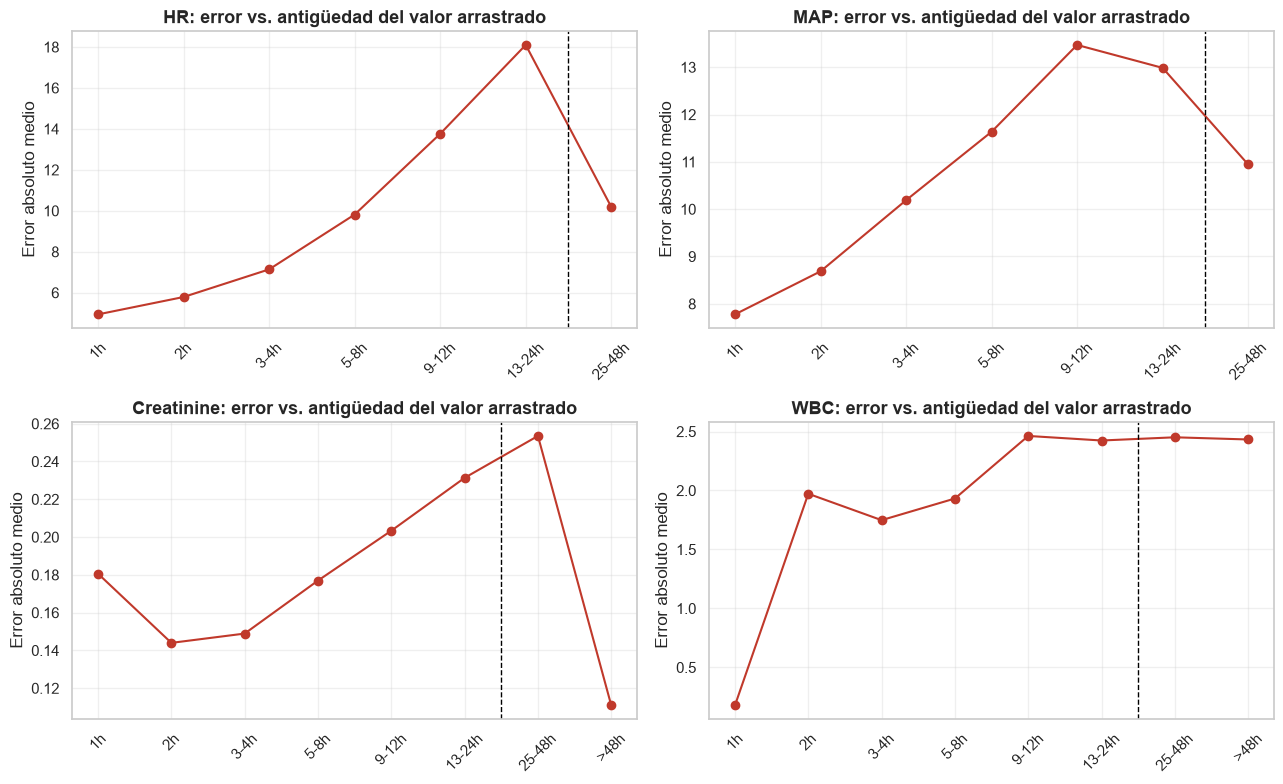

In [3]:
def pares_consecutivos(var):
    obs = df.loc[df[var].notna(), ["pid", "ICULOS", var]].copy()
    obs["t_prev"] = obs.groupby("pid", observed=True)["ICULOS"].shift(1)
    obs["val_prev"] = obs.groupby("pid", observed=True)[var].shift(1)
    obs = obs.dropna(subset=["t_prev", "val_prev"])
    obs["gap"] = obs["ICULOS"] - obs["t_prev"]
    obs["error_abs"] = (obs[var] - obs["val_prev"]).abs()
    return obs


bins = [0, 1, 2, 4, 8, 12, 24, 48, np.inf]
etiquetas_gap = ["1h", "2h", "3-4h", "5-8h", "9-12h", "13-24h", "25-48h", ">48h"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, var in zip(axes.flat, ["HR", "MAP", "Creatinine", "WBC"]):
    p = pares_consecutivos(var)
    p["bin_gap"] = pd.cut(p["gap"], bins=bins, labels=etiquetas_gap)
    resumen = p.groupby("bin_gap", observed=True)["error_abs"].mean()
    ax.plot(range(len(resumen)), resumen.values, marker="o", color=viz.COLOR_SEPSIS)
    ax.set_xticks(range(len(resumen)))
    ax.set_xticklabels(resumen.index, rotation=45)
    ax.axvline(5.5, color="black", ls="--", lw=1)  # frontera de las 24h (índice del bin "13-24h")
    ax.set_title(f"{var}: error vs. antigüedad del valor arrastrado")
    ax.set_ylabel("Error absoluto medio")
plt.tight_layout()
viz.guardar(fig, "04_error_arrastre_vs_antiguedad_valor", cfg)

Los signos vitales degradan rápido y de forma limpia: el error de `HR` casi se **cuadruplica**
entre un hueco de 1 hora (4,94) y uno de 13-24h (18,10); `MAP` crece más suave pero también
consistente (7,78 → 12,99). Los laboratorios cuentan otra historia: `Creatinine` apenas
empeora con el tiempo (0,18 a 1h, 0,23 incluso a las 25-48h) — es una variable fisiológicamente
"lenta", coherente con lo que ya vimos en la Sección 2. `WBC` tiene un salto raro justo en el
segundo bin (0,18 → 1,97) que no sigue el patrón suave esperado — probablemente refleja
mediciones repetidas de control de calidad muy próximas en el tiempo, más que una degradación
real; no le damos más peso del que merece dado lo puntual del patrón.

**Decisión**: mantenemos el tope único de 24 horas (`max_horas_ffill` en `config.yaml`) para
todas las variables. No es óptimo para cada una por separado —a `Creatinine` seguramente le
sobraría margen— pero es defendible como compromiso: coincide con el horizonte clínico
relevante del proyecto (el utility score premia detectar hasta 12h antes del evento) y evita
la complejidad de mantener un tope distinto por variable sin evidencia suficiente de que valga
la pena el costo de mantenimiento adicional.

## 4. El efecto visual de imputar con la media global

Antes de descartar la media global solo por el número de MAE, vale la pena verla. Comparamos
la distribución real de `Creatinine` (solo los valores medidos) contra cómo quedaría esa misma
columna si tapáramos **todos** sus nulos con la media global.

% de la columna que sería exactamente 1.5107 tras esta imputación: 93.9%


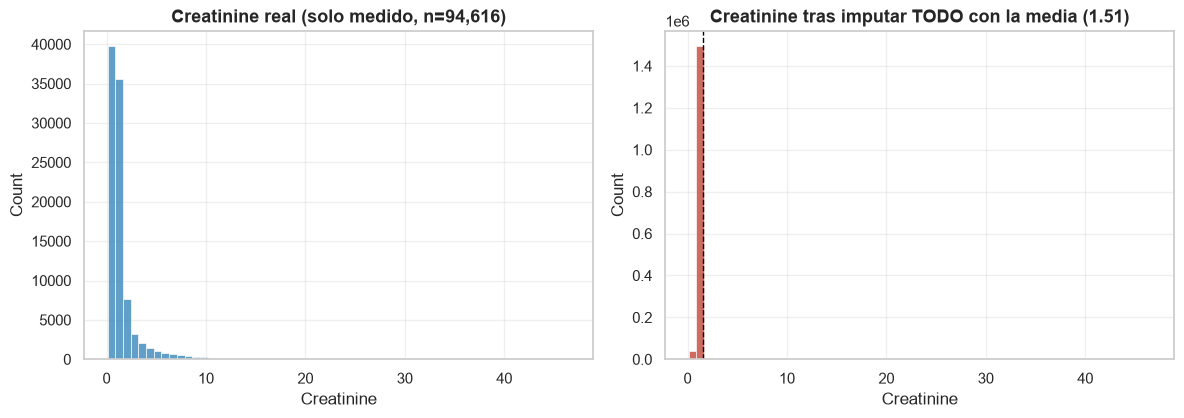

In [4]:
real_creat = df["Creatinine"].dropna()
media_creat = real_creat.mean()
imputado_ingenuo = df["Creatinine"].fillna(media_creat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
sns.histplot(real_creat, bins=60, color=viz.COLOR_CONTROL, ax=axes[0])
axes[0].set_title(f"Creatinine real (solo medido, n={len(real_creat):,})")

sns.histplot(imputado_ingenuo, bins=60, color=viz.COLOR_SEPSIS, ax=axes[1])
axes[1].axvline(media_creat, color="black", ls="--", lw=1)
axes[1].set_title(f"Creatinine tras imputar TODO con la media ({media_creat:.2f})")
plt.tight_layout()
viz.guardar(fig, "04_creatinine_real_vs_imputada_media_global", cfg)

print(f"% de la columna que sería exactamente {media_creat:.4f} tras esta imputación: "
      f"{df['Creatinine'].isna().mean() * 100:.1f}%")

La distribución real de `Creatinine` es asimétrica, con una cola larga hacia valores altos
(propia de disfunción renal). Después de imputar con la media global aparece una **aguja
artificial** en 1,50: el 93,9% de la columna —todo lo que era nulo— pasa a valer exactamente
ese número. Cualquier modelo vería una moda dominante que no existe en la fisiología real, y
cualquier estadístico calculado después (varianza, percentiles, hasta la propia importancia de
la variable) quedaría distorsionado por un valor inventado, no observado.

## 5. Política de imputación final

La tabla resume lo que la evidencia de las secciones 2-4 sostiene, y coincide exactamente con
lo que ya implementa `src/features.py`:

| Tipo de variable | Ejemplos | Método | Por qué (evidencia) |
|---|---|---|---|
| Signos vitales | `HR`, `MAP`, `Resp`, `SBP` | Arrastre causal, tope 24h (`valor_arrastrado`) | MAE 3-4x menor que la media global (Sección 2); error crece con la antigüedad, tope se apoya en la Sección 3 |
| Labs con densidad media | `Temp`, `Glucose` | Arrastre causal, mismo tope | Mismo mecanismo que los vitales, densidad suficiente para que el arrastre cubra la mayoría de las horas |
| Labs dispersos (>90% nulo) | `Creatinine`, `WBC`, `Lactate`, etc. | Arrastre causal **+ indicador de medición + antigüedad**, nunca imputación global | La cobertura del arrastre cae a ~53-55% (Sección 2): casi la mitad de las horas se queda sin valor arrastrable, y eso hay que dejarlo visible, no taparlo con una media que distorsiona la distribución (Sección 4) |
| Todas | — | Nunca `interpolate()` ni estadísticos de toda la estancia | Usan información futura — fuga de datos por definición (Sección "regla que no se negocia") |

Esto es exactamente lo que hace `features.valor_arrastrado()` (arrastre + tope + columna de
antigüedad) combinado con `features.indicadores_medicion()` (el indicador binario) — ya
escritas y lista para usarse desde antes de este análisis, y ahora con la justificación
empírica que les faltaba.

## 6. Qué sabemos al cerrar este notebook

- **El arrastre causal gana a la media global en todos los casos probados**, con MAE 2-7 veces
  menor, sin necesidad de hacer trampa con información futura.
- **La "trampa" (mediana de toda la estancia) a veces gana por poco al arrastre honesto, y a
  veces ni eso**: en `HR` el arrastre causal fue mejor incluso que la trampa. La ventaja de
  hacer trampa no es tan grande como parece, y nunca compensa el riesgo de fuga.
- **El problema real de los laboratorios dispersos no es el error del método, es la
  cobertura**: casi la mitad de las horas se quedan sin ningún valor previo que arrastrar.
  Ahí es donde el indicador de medición y la antigüedad hacen el trabajo pesado.
- **El error del arrastre crece con el tiempo, pero a ritmos muy distintos por variable**: los
  vitales se degradan rápido (justifica un tope), los labs "lentos" como `Creatinine` casi no
  cambian ni en 48 horas.
- **La imputación global no solo pierde precisión — deforma la distribución**: crea una moda
  artificial que no existe en los datos reales.

➡️ Siguiente: `05_feature_engineering.ipynb` — con la política de imputación ya validada,
construimos la matriz completa de features sobre toda la cohorte usando `features.construir_matriz()`.